# DDIM vs DDPM on a pretrained DDPM

This notebook loads **`google/ddpm-cifar10-32`** (32×32 unconditional CIFAR-10), runs **DDPM** (from diffusers) and **DDIM** implemented with our **`DDIMSchedulerAdapter`** (see `sampling/ddim.py`, `sampling/scheduler.py`), then compares **wall-clock time**, **diversity** proxies, and **side-by-side visuals** against DDPM and a **diffusers** `DDIMScheduler` reference (no clipping in either DDIM path for a fair match).

Implementation lives in the installable package `find_delft_assignment` (`sampling/ddpm.py`, `sampling/ddim.py`).

In [1]:
# --- Run once: install (local vs Colab) ---
import subprocess
import sys


def _pip_install(args: list[str]) -> None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *args])


COLAB_INSTALL_URL: str | None = None

try:
    import google.colab  # type: ignore  # noqa: F401
except ImportError:
    _pip_install(["-e", ".."])
else:
    if not COLAB_INSTALL_URL:
        raise RuntimeError(
            "Set COLAB_INSTALL_URL in this cell to your git URL, then re-run (see README / colab/README.md)."
        )
    _pip_install([COLAB_INSTALL_URL])

In [2]:
from __future__ import annotations

import os
import time

import torch

from find_delft_assignment import __version__
from find_delft_assignment.config import SamplingConfig
from find_delft_assignment.metrics.basic import TimedResult, pixel_diversity
from find_delft_assignment.model.pretrained import load_pretrained_ddpm
from find_delft_assignment.sampling.ddim import ddim_sample
from find_delft_assignment.sampling.ddpm import ddpm_sample
from find_delft_assignment.utils.reproduce import set_seed
from find_delft_assignment.visualisation.grids import save_image_grid

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("package", __version__, "| device", device)

/home/com3dian/Github/FIND_Delft_Assignment/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


package 0.1.0 | device cpu


In [3]:
SEED = 0
BATCH = 16
set_seed(SEED)
gen = torch.Generator(device=device).manual_seed(SEED)

bundle = load_pretrained_ddpm()
print("Loaded", bundle.model_id, "| image", bundle.image_size, "| ch", bundle.in_channels)

Loading pipeline components...: 100%|██████████| 2/2 [00:00<00:00, 49.76it/s]

Loaded google/ddpm-cifar10-32 | image 32 | ch 3


In [4]:
# Full DDPM chain (1000 steps) — slow but Markov-consistent with training noise injection.
cfg_ddpm = SamplingConfig.from_pretrained(bundle, num_inference_steps=1000, seed=SEED)

if torch.cuda.is_available():
    torch.cuda.synchronize()
t0 = time.perf_counter()
ddpm_images = ddpm_sample(
    bundle.unet,
    bundle.ddpm_scheduler,
    cfg_ddpm,
    batch_size=BATCH,
    device=device,
    generator=gen,
    show_progress=True,
)
if torch.cuda.is_available():
    torch.cuda.synchronize()
ddpm_sec = time.perf_counter() - t0

out = os.path.join("..", "outputs", "notebook")
os.makedirs(out, exist_ok=True)
save_image_grid(ddpm_images, os.path.join(out, "grid_ddpm_1000.png"))

tr = TimedResult(seconds=ddpm_sec, batch_size=BATCH, num_inference_steps=1000)
print("DDPM", tr, "sec/img", tr.seconds_per_image, "steps/s", tr.steps_per_second)
print("diversity", pixel_diversity(ddpm_images))

DDPM TimedResult(seconds=383.5389979160027, batch_size=16, num_inference_steps=1000) sec/img 23.97118736975017 steps/s 41.71674871900274
diversity {'mean_pairwise_l2': 32.243934631347656, 'channel_std_mean': 0.416238933801651}


In [5]:
# DDIM with fewer steps — `ddim_sample` uses our `DDIMSchedulerAdapter` (eta=0 → deterministic given noise).


def run_ddim(steps: int) -> tuple[torch.Tensor, float]:
    set_seed(SEED)
    g = torch.Generator(device=device).manual_seed(SEED)
    cfg = SamplingConfig.from_pretrained(bundle, num_inference_steps=steps, eta=0.0, seed=SEED)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    imgs = ddim_sample(
        bundle.unet,
        bundle.ddpm_scheduler,
        cfg,
        batch_size=BATCH,
        device=device,
        generator=g,
        show_progress=True,
    )
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    return imgs, time.perf_counter() - t0


ddim_images_by_steps: dict[int, torch.Tensor] = {}
ddim_sec_by_steps: dict[int, float] = {}

for steps in (50, 200, 1000):
    imgs, sec = run_ddim(steps)
    ddim_images_by_steps[steps] = imgs
    ddim_sec_by_steps[steps] = sec
    tr = TimedResult(seconds=sec, batch_size=BATCH, num_inference_steps=steps)
    save_image_grid(imgs, os.path.join(out, f"grid_ddim_adapter_{steps}.png"))
    print(f"DDIM (adapter) steps={steps}", "sec/img", tr.seconds_per_image, "diversity", pixel_diversity(imgs))

DDIM (adapter) steps=50 sec/img 1.2484043084377845 diversity {'mean_pairwise_l2': 33.63755798339844, 'channel_std_mean': 0.4370757043361664}


DDIM (adapter) steps=200 sec/img 4.853974063062651 diversity {'mean_pairwise_l2': 34.94743347167969, 'channel_std_mean': 0.45347273349761963}


DDIM (adapter) steps=1000 sec/img 24.65962511456246 diversity {'mean_pairwise_l2': 35.34101104736328, 'channel_std_mean': 0.45845553278923035}


## Visual comparison

Rows: **DDPM (1000)** vs **our DDIM** at each step count. Columns are independent samples (same column is *not* paired across rows unless you fix the initial noise API). The block below also checks **max |diff|** vs **diffusers** `DDIMScheduler` (`clip_sample=False`) at 50 steps.

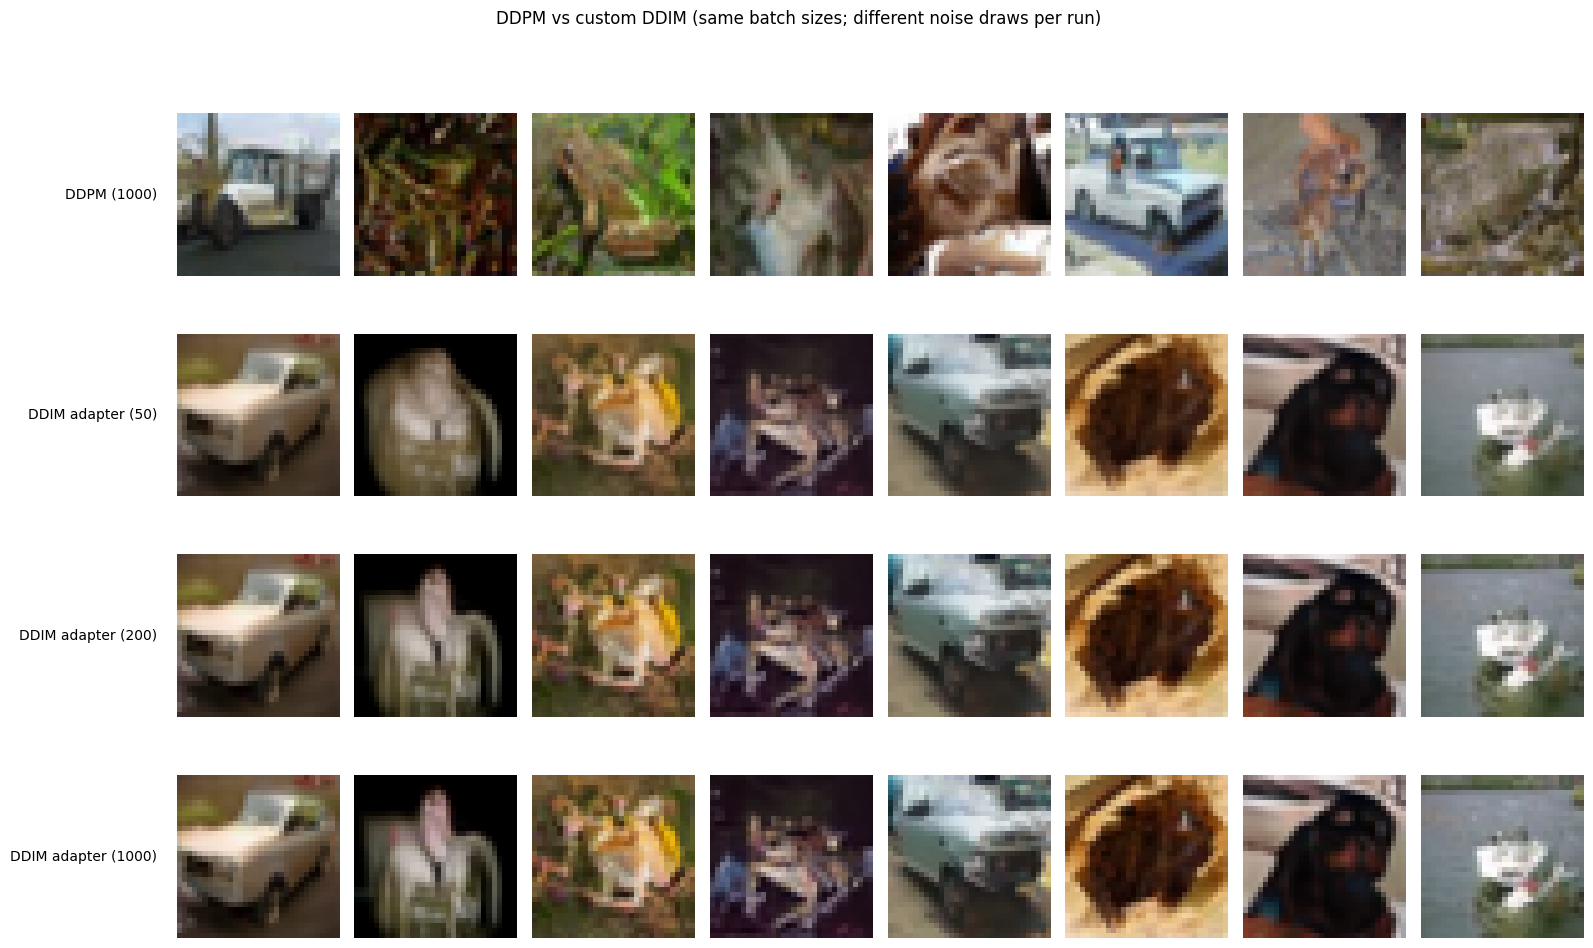

Max |diffusers - adapter| at 50 steps: 0.000e+00


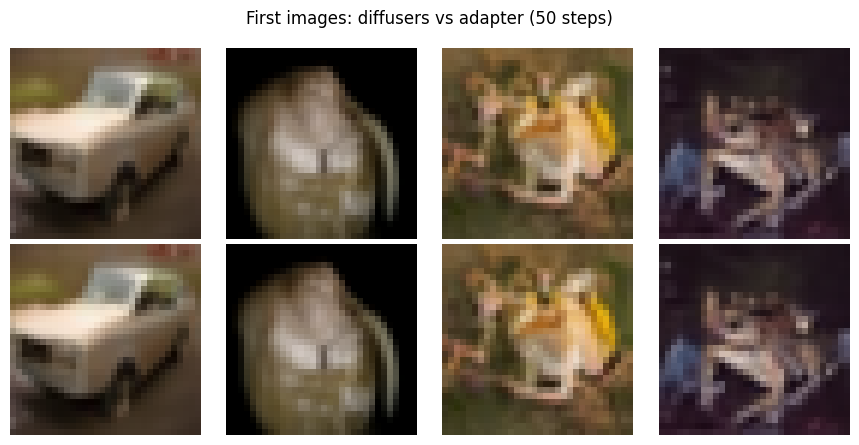

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from diffusers import DDIMScheduler

from find_delft_assignment.sampling.common import unet_predict_noise

COLS = min(8, BATCH)


def _to_hwc(img_chw: torch.Tensor) -> np.ndarray:
    x = img_chw.detach().float().cpu().clamp(-1.0, 1.0)
    x = (x + 1.0) * 0.5
    return x.permute(1, 2, 0).numpy()


rows: list[tuple[str, torch.Tensor]] = [("DDPM (1000)", ddpm_images)]
for s in sorted(ddim_images_by_steps.keys()):
    rows.append((f"DDIM adapter ({s})", ddim_images_by_steps[s]))

n_r = len(rows)
fig, axes = plt.subplots(n_r, COLS, figsize=(2.0 * COLS, 2.4 * n_r), squeeze=False)
for i, (name, batch) in enumerate(rows):
    for j in range(COLS):
        axes[i, j].imshow(_to_hwc(batch[j]))
        axes[i, j].axis("off")
    axes[i, 0].annotate(
        name,
        xy=(-0.12, 0.5),
        xycoords="axes fraction",
        va="center",
        ha="right",
        fontsize=10,
    )
plt.suptitle("DDPM vs custom DDIM (same batch sizes; different noise draws per run)", y=1.02)
plt.tight_layout()
plt.show()


def _ddim_diffusers_reference(steps: int) -> torch.Tensor:
    """Same loop as diffusers DDIMScheduler (no x0 clip) for numeric check."""
    set_seed(SEED)
    g = torch.Generator(device=device).manual_seed(SEED)
    cfg = SamplingConfig.from_pretrained(bundle, num_inference_steps=steps, eta=0.0, seed=SEED)
    unet = bundle.unet.to(device)
    unet.eval()
    dtype = next(unet.parameters()).dtype
    h = w = cfg.image_size
    sched = DDIMScheduler.from_config(bundle.ddpm_scheduler.config, clip_sample=False)
    sched.set_timesteps(cfg.num_inference_steps, device=device)
    x = torch.randn(
        (BATCH, cfg.in_channels, h, w),
        generator=g,
        device=device,
        dtype=dtype,
    )
    with torch.inference_mode():
        for t in sched.timesteps:
            ti = int(t.item())
            eps = unet_predict_noise(unet, x, t)
            x = sched.step(eps, ti, x, eta=0.0, generator=g).prev_sample
    return x


cmp_steps = 50
if cmp_steps in ddim_images_by_steps:
    ref = _ddim_diffusers_reference(cmp_steps)
    ours = ddim_images_by_steps[cmp_steps]
    md = (ref - ours).abs().max().item()
    print(f"Max |diffusers - adapter| at {cmp_steps} steps: {md:.3e}")
    fig2, axes2 = plt.subplots(2, min(4, COLS), figsize=(2.2 * min(4, COLS), 4.5), squeeze=False)
    for j in range(min(4, COLS)):
        axes2[0, j].imshow(_to_hwc(ref[j]))
        axes2[0, j].axis("off")
        axes2[1, j].imshow(_to_hwc(ours[j]))
        axes2[1, j].axis("off")
    axes2[0, 0].set_ylabel("diffusers", fontsize=9)
    axes2[1, 0].set_ylabel("adapter", fontsize=9)
    fig2.suptitle(f"First images: diffusers vs adapter ({cmp_steps} steps)")
    plt.tight_layout()
    plt.show()

## Takeaways (after running)

- **Speed**: DDIM with 50–200 steps is usually much faster than a full 1000-step DDPM chain; cost scales roughly with the number of UNet evaluations.
- **Quality**: Very few DDIM steps can lose fine detail; inspect the PNG grids under `outputs/notebook/` (`grid_ddim_adapter_*.png`).
- **Custom DDIM**: `ddim_sample` uses `DDIMSchedulerAdapter`; the notebook prints max deviation vs diffusers `DDIMScheduler` at 50 steps (should be ~0).
- **Diversity**: Both methods use independent noise per image; DDIM with `eta=0` is deterministic for a fixed noise tensor, while DDPM remains stochastic at every step.

Re-run this notebook (or use the same imports in a small script) to reproduce; see root `README.md` for setup.